# 03 - Outliers and Validation
**Goal:** Validate the currency conversion, remove implausible salaries and experience values, and produce the final clean dataset for analysis.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IN_PATH = PROCESSED_DIR / "stage1_salary_rows.csv"
assert IN_PATH.exists(), f"File not found: {IN_PATH.resolve()}"

df = pd.read_csv(IN_PATH, low_memory=False)
TARGET = "ConvertedCompYearly"

# Track how many rows each cleaning step removes (used later for the README)
cleaning_log = [("Start of this notebook", len(df))]
print(f"Loaded shape: {df.shape}")

Loaded shape: (22550, 13)


In [13]:
# The Currency column looks like "USD\tUnited States dollar"; keep the 3-letter code
df["CurrencyCode"] = df["Currency"].str.extract(r"^([A-Za-z]{3})", expand=False).str.upper()

# Implied exchange rate = converted salary / original salary
valid = df["CompTotal"] > 0
df["implied_rate"] = np.where(valid, df[TARGET] / df["CompTotal"], np.nan)

rate_summary = (
    df.dropna(subset=["implied_rate"])
      .groupby("CurrencyCode")["implied_rate"]
      .agg(n="count", median_rate="median", min_rate="min", max_rate="max")
      .sort_values("n", ascending=False)
)
print("Top currencies and their implied USD rate:")
display(rate_summary.head(10))

# If the conversion is consistent, every row of a currency uses (almost) the same rate
median_rate = df.groupby("CurrencyCode")["implied_rate"].transform("median")
mismatch = (df["implied_rate"] / median_rate - 1).abs() > 0.01

print(f"\nRows whose rate deviates >1% from their currency's median rate: "
      f"{mismatch.sum():,} ({mismatch.mean():.2%})")

print("\nExamples of inconsistent conversions:")
display(df.loc[mismatch, ["Country", "Currency", "CompTotal", TARGET, "implied_rate"]].head(10))

# Drop rows whose USD value cannot be trusted
df = df[~mismatch].copy()
cleaning_log.append(("Inconsistent currency conversion removed", len(df)))
print(f"\nRows remaining: {len(df):,}")

Top currencies and their implied USD rate:


,n,median_rate,min_rate,max_rate
CurrencyCode,,,,
EUR,6510,1.160147,1.000000,1.200000
USD,5924,1.000000,1.000000,1.000000
GBP,1429,1.361415,1.000000,1.375000
INR,990,0.011624,0.011500,0.022222
CAD,853,0.729584,0.725926,0.800000
BRL,558,0.182037,0.177419,0.183333
AUD,531,0.650093,0.650000,0.657143
PLN,516,0.272900,0.267857,0.273333
SEK,445,0.104822,0.100000,0.105000



Rows whose rate deviates >1% from their currency's median rate: 88 (0.39%)

Examples of inconsistent conversions:


,Country,Currency,CompTotal,ConvertedCompYearly,implied_rate
44,Japan,JPY\tJapanese yen,500.0,3.0,0.006000
61,India,INR Indian rupee,50.0,1.0,0.020000
196,Turkey,TRY\tTurkish lira,100.0,3.0,0.030000
525,Colombia,COP\tColombian peso,88200.0,22.0,0.000249
815,Tunisia,TND\tTunisian dinar,19.0,6.0,0.315789
2408,Japan,JPY\tJapanese yen,350.0,2.0,0.005714
2602,Serbia,RSD\tSerbian dinar,3500.0,35.0,0.010000
3217,Ukraine,UAH Ukrainian hryvnia,900.0,22.0,0.024444
3511,Brazil,BRL Brazilian real,100.0,18.0,0.180000
3938,Indonesia,IDR\tIndonesian rupiah,120000.0,7.0,0.000058



Rows remaining: 22,462


In [14]:
print(df[TARGET].describe(percentiles=[.001, .01, .05, .5, .95, .99, .999]).round(0))

print("\nRows below fixed thresholds:")
for t in [100, 1_000, 5_000, 10_000]:
    print(f"  < ${t:>9,}: {(df[TARGET] < t).sum():>5,}")

print("\nRows above fixed thresholds:")
for t in [500_000, 1_000_000, 5_000_000]:
    print(f"  > ${t:>9,}: {(df[TARGET] > t).sum():>5,}")

print("\nTop 10 highest salaries:")
display(df.nlargest(10, TARGET)[["Country", "Currency", "CompTotal", TARGET, "WorkExp", "DevType"]])

count       22462.0
mean       104725.0
std        470105.0
min             1.0
0.1%           22.0
1%            197.0
5%           4214.0
50%         78308.0
95%        235000.0
99%        449553.0
99.9%     1498873.0
max      50000000.0
Name: ConvertedCompYearly, dtype: float64

Rows below fixed thresholds:
  < $      100:   141
  < $    1,000:   458
  < $    5,000: 1,255
  < $   10,000: 2,002

Rows above fixed thresholds:
  > $  500,000:   170
  > $1,000,000:    41
  > $5,000,000:    11

Top 10 highest salaries:


,Country,Currency,CompTotal,ConvertedCompYearly,WorkExp,DevType
16327,United States,USD United States dollar,5.000000e+07,50000000.0,10.0,"Developer, embedded applications or devices"
14263,Ukraine,UAH Ukrainian hryvnia,1.400000e+09,33552715.0,20.0,"Developer, full-stack"
20443,Poland,BRL Brazilian real,1.010101e+08,18387548.0,10.0,Financial analyst or engineer
16875,"Iran, Islamic Republic of...",IRR\tIranian rial,6.500000e+11,15430267.0,15.0,Engineering manager
21646,Netherlands,EUR European Euro,1.200000e+07,13921760.0,30.0,"Senior executive (C-suite, VP, etc.)"
12507,India,INR Indian rupee,8.200000e+08,9531653.0,1.0,"Developer, full-stack"
5503,United States,USD United States dollar,9.000000e+06,9000000.0,2.0,Academic researcher
17930,Ukraine,UAH Ukrainian hryvnia,2.875004e+08,6890299.0,15.0,"Developer, full-stack"
15174,Brazil,BRL Brazilian real,3.500000e+07,6371285.0,17.0,"Developer, back-end"
19265,Viet Nam,USD United States dollar,6.000000e+06,6000000.0,10.0,System administrator


In [15]:
# Domain-knowledge bounds (change these two numbers if you disagree, then re-run).
# Below the floor: almost surely typos, monthly/hourly values, or wrong currency.
# Above the ceiling: almost surely extra zeros or wrong currency.
SALARY_FLOOR = 1_000
SALARY_CEILING = 1_000_000

before = len(df)
df = df[(df[TARGET] >= SALARY_FLOOR) & (df[TARGET] <= SALARY_CEILING)].copy()

print(f"Removed by absolute bounds: {before - len(df):,}")
cleaning_log.append((f"Salary between ${SALARY_FLOOR:,} and ${SALARY_CEILING:,}", len(df)))

Removed by absolute bounds: 499


In [16]:
# Work on the log scale because salaries are multiplicative (log-normal shape).
# Use a generous 3 x IQR fence so we only remove clearly extreme values.
IQR_K = 3.0
MIN_GROUP_SIZE = 30   # small countries do not have enough data for a reliable fence

def flag_country_outliers(frame, value_col, group_col="Country", k=IQR_K, min_group=MIN_GROUP_SIZE):
    """Return a boolean Series: True where the log-salary is extreme for its country."""
    log_val = np.log10(frame[value_col])
    grp = log_val.groupby(frame[group_col])
    q1 = grp.transform(lambda s: s.quantile(0.25))
    q3 = grp.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    size = grp.transform("size")
    outside = (log_val < q1 - k * iqr) | (log_val > q3 + k * iqr)
    return outside & (size >= min_group)

df["is_country_outlier"] = flag_country_outliers(df, TARGET)
print(f"Flagged as country outliers: {df['is_country_outlier'].sum():,}")

print("\nCountries with the most flagged rows:")
print(df[df["is_country_outlier"]].groupby("Country").size().sort_values(ascending=False).head(8))

print("\nA sample of flagged rows:")
display(df[df["is_country_outlier"]][["Country", "CompTotal", "CurrencyCode", TARGET, "WorkExp"]].head(10))

Flagged as country outliers: 261

Countries with the most flagged rows:
Country
Germany           51
United States     47
Sweden            23
Denmark           13
Australia          9
Finland            9
Switzerland        9
Czech Republic     9
dtype: int64

A sample of flagged rows:


,Country,CompTotal,CurrencyCode,ConvertedCompYearly,WorkExp
52,United States,5000.0,USD,5000.0,22.0
123,Sweden,110000.0,SEK,11530.0,26.0
354,Germany,12660.0,EUR,14687.0,1.0
410,Sweden,150000.0,SEK,15723.0,10.0
683,Austria,3077.0,EUR,3570.0,3.0
693,Canada,10500.0,CAD,7661.0,25.0
763,France,800000.0,EUR,928117.0,8.0
821,Norway,200000.0,NOK,19765.0,4.0
992,Italy,2000.0,EUR,2320.0,40.0
1130,Poland,7000.0,PLN,1910.0,17.0


In [17]:
before = len(df)
df = df[~df["is_country_outlier"]].copy()
df = df.drop(columns="is_country_outlier")

print(f"Removed by country-level IQR fence: {before - len(df):,}")
cleaning_log.append((f"Country-level outliers removed ({IQR_K} x IQR on log scale)", len(df)))

Removed by country-level IQR fence: 261


In [18]:
print(df["Age"].value_counts(dropna=False))

Age
25-34 years old      7938
35-44 years old      7178
45-54 years old      3229
18-24 years old      1853
55-64 years old      1274
65 years or older     218
Prefer not to say      12
Name: count, dtype: int64


In [19]:
# Upper age bound of each bucket; the open-ended bucket "65 years or older" is capped at 80.
AGE_UPPER = {
    "Under 18 years old": 17,
    "18-24 years old": 24,
    "25-34 years old": 34,
    "35-44 years old": 44,
    "45-54 years old": 54,
    "55-64 years old": 64,
    "65 years or older": 80,
}
MIN_WORKING_AGE = 14        # nobody starts a professional career before this age
MAX_EXP_UNKNOWN_AGE = 50    # fallback when Age is unknown ("Prefer not to say")

# Maximum possible experience for each respondent given their age bucket
max_exp_by_age = (df["Age"].map(AGE_UPPER) - MIN_WORKING_AGE).fillna(MAX_EXP_UNKNOWN_AGE)

invalid_exp = df["WorkExp"] > max_exp_by_age    # False when WorkExp is NaN
print(f"WorkExp values set to NaN: {invalid_exp.sum():,}")
display(df.loc[invalid_exp, ["Age", "WorkExp", TARGET]].head(10))

df.loc[invalid_exp, "WorkExp"] = np.nan
print(df["WorkExp"].describe().round(1))

WorkExp values set to NaN: 19


,Age,WorkExp,ConvertedCompYearly
1117,55-64 years old,55.0,150000.0
1209,35-44 years old,35.0,225000.0
1413,18-24 years old,50.0,136450.0
7399,35-44 years old,45.0,300000.0
7731,25-34 years old,25.0,21844.0
8392,25-34 years old,23.0,70208.0
9147,18-24 years old,100.0,336327.0
10535,65 years or older,68.0,36847.0
11548,35-44 years old,100.0,444449.0
12420,35-44 years old,35.0,25519.0


count    21477.0
mean        13.8
std          9.7
min          1.0
25%          6.0
50%         12.0
75%         20.0
max         65.0
Name: WorkExp, dtype: float64


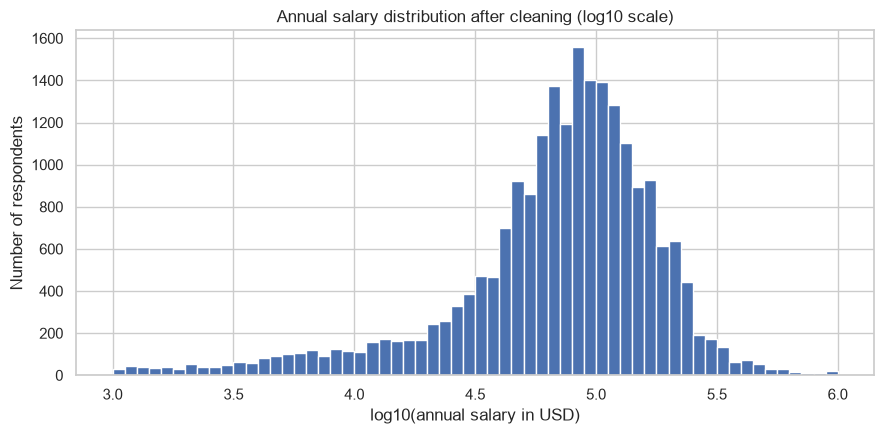

count      21702.0
mean       97395.0
std        83341.0
min         1000.0
1%          2000.0
25%        46406.0
50%        81210.0
75%       125786.0
99%       400000.0
max      1000000.0
Name: ConvertedCompYearly, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(np.log10(df[TARGET]), bins=60, color="#4C72B0", edgecolor="white")
ax.set_title("Annual salary distribution after cleaning (log10 scale)")
ax.set_xlabel("log10(annual salary in USD)")
ax.set_ylabel("Number of respondents")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "salary_distribution_clean.png", dpi=150)
plt.show()

print(df[TARGET].describe(percentiles=[.01, .25, .5, .75, .99]).round(0))

In [21]:
# Drop helper columns that were only needed for validation
df = df.drop(columns=["implied_rate"])

OUT_PATH = PROCESSED_DIR / "clean_salaries.csv"
df.to_csv(OUT_PATH, index=False)

summary = pd.DataFrame(cleaning_log, columns=["step", "rows_remaining"])
summary["rows_removed"] = (-summary["rows_remaining"].diff()).fillna(0).astype(int)
display(summary)

print(f"\nSaved: {OUT_PATH.resolve()}")
print(f"Final shape: {df.shape}")

,step,rows_remaining,rows_removed
0,Start of this notebook,22550,0
1,Inconsistent currency conversion removed,22462,88
2,"Salary between $1,000 and $1,000,000",21963,499
3,Country-level outliers removed (3.0 x IQR on log scale),21702,261



Saved: D:\tech-salary-analysis\data\processed\clean_salaries.csv
Final shape: (21702, 14)
